# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [2]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [3]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [5]:

now = Time.now()
print("UTC:", now.utc.isot)
print("IIT Kanpur:", format_iitk(now))


# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

UTC: 2026-09-06T10:58:22.231
IIT Kanpur: 2026-09-06 16:28:22 IST


Explanation : There is a time gap between these two calls , that's why they're not representing exactly same instant.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [6]:
gtc_height = 2396 * u.m
wavelength = 600 * u.nm
coord_uncertainty = 5 * u.mas
cadence = 10 * u.min
radio_frequency = 1.4 * u.GHz

print(f"GTC height: {gtc_height} = {gtc_height.to(u.km)}")
print(f"Wavelength: {wavelength} = {wavelength.to(u.THz, equivalencies=u.spectral())}")
print(f"Coordinate uncertainty: {coord_uncertainty} = {coord_uncertainty.to(u.arcsec)}")
print(f"Cadence: {cadence} = {cadence.to(u.hour)}")
print(f"Radio frequency: {radio_frequency} = {radio_frequency.to(u.cm, equivalencies=u.spectral())}")


# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

GTC height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Radio frequency: 1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [7]:
planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.isot)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour
print("\nLater instant:")
print("UTC:", later.utc.isot)
print("IIT Kanpur:", format_iitk(later))

original_ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
round_trip = Time(original_ist_datetime)
difference_us = abs((round_trip - planning_start).to_value(u.s)) * 1e6

print("\nIST datetime round-trip difference:", difference_us, "microseconds")
assert difference_us < 1.0


# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

UTC: 2026-08-30T12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST

Later instant:
UTC: 2026-08-30T14:15:00.000
IIT Kanpur: 2026-08-30 19:45:00 IST

IST datetime round-trip difference: 0.0 microseconds


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [8]:
ra_angle = Angle(FRB_RA_J2000)
dec_angle = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(ra=ra_angle, dec=dec_angle, frame="icrs")

print("RA (deg):", frb_icrs.ra.deg)
print("Dec (deg):", frb_icrs.dec.deg)
print("RA (sexagesimal):", frb_icrs.ra.to_string(unit=u.hourangle, sep="hms", pad=True, precision=4))
print("Dec (sexagesimal):", frb_icrs.dec.to_string(unit=u.deg, sep="dms", alwayssign=True, pad=True, precision=4))

assert abs(frb_icrs.ra.deg - 347.2704120833) < 1e-8
assert abs(frb_icrs.dec.deg - 48.7066410556) < 1e-8

# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

RA (deg): 347.27041208333327
Dec (deg): 48.70664105555556
RA (sexagesimal): 23h09m04.8989s
Dec (sexagesimal): +48d42m23.9078s


Explanation : RA uses hours because earth's 1 rotation takes 24 hours means completing 360 degree in 24 Hours , so roating 15 degree indicates 1 Hour. Dec uses degree because it represents angular distance towards north or south from celestial equator and it ranges only from +90 degree to -90 degree.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [9]:
frb_galactic = frb_icrs.galactic

print("Galactic longitude l:", frb_galactic.l.deg, "deg")
print("Galactic latitude b:", frb_galactic.b.deg, "deg")

roundtrip_icrs_gal = frb_galactic.icrs
roundtrip_sep = frb_icrs.separation(roundtrip_icrs_gal).to(u.microarcsecond)

print("Round-trip separation:", roundtrip_sep)




Galactic longitude l: 106.06496077332801 deg
Galactic latitude b: -10.784176285402495 deg
Round-trip separation: 0.000289774 uarcsec


Explanation : Ideally seperation is 0 , but here it is showing a very small value . This small value is the error came after the arithmatic operation . Because computer arithmetic cannot represent the operations with absolutely infinite precision.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [10]:
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox=Time("J2000", scale="tt"))
)

lam = frb_ecliptic.lon
beta = frb_ecliptic.lat

print("Ecliptic longitude lambda:", lam.deg, "deg")
print("Ecliptic latitude beta:", beta.deg, "deg")

assert 0 <= lam.deg < 360
assert -90 <= beta.deg <= 90

roundtrip_icrs_ecl = frb_ecliptic.transform_to("icrs")
roundtrip_sep_ecl = frb_icrs.separation(roundtrip_icrs_ecl).to(u.microarcsecond)

print("Round-trip separation:", roundtrip_sep_ecl)




Ecliptic longitude lambda: 14.411187650340095 deg
Ecliptic latitude beta: 48.34695843744783 deg
Round-trip separation: 0 uarcsec


Explanation : The ecliptic plane is the path of sun traced in 1 year in earth's atmosphere . The value of beta represents how far an object appears above or below the celestial plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [11]:
earlier_position = SkyCoord(
    ra=Angle(EARLIER_POSITION_RA),
    dec=Angle(EARLIER_POSITION_DEC),
    frame="icrs",
)

ra1 = frb_icrs.ra.to_value(u.rad)
dec1 = frb_icrs.dec.to_value(u.rad)
ra2 = earlier_position.ra.to_value(u.rad)
dec2 = earlier_position.dec.to_value(u.rad)

cos_sep = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1)
)
cos_sep = np.clip(cos_sep, -1.0, 1.0)

delta_theta_rad = np.arccos(cos_sep)
delta_theta = delta_theta_rad * u.rad

astropy_sep = frb_icrs.separation(earlier_position)

print("Manual separation:", delta_theta.to(u.arcsec))
print("Manual separation:", delta_theta.to(u.mas))
print("Astropy separation:", astropy_sep.to(u.arcsec))
print("Difference:", abs(delta_theta - astropy_sep).to(u.arcsec))

assert abs((delta_theta - astropy_sep).to_value(u.arcsec)) < 1e-6

# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Manual separation: 1.4922374490540065 arcsec
Manual separation: 1492.2374490540062 mas
Astropy separation: 1.49224 arcsec
Difference: 2.27715e-06 arcsec


AssertionError: 

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [12]:
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m,
)

lon, lat, height = gtc_location.to_geodetic()

print("Longitude:", lon)
print("Latitude:", lat)
print("Height:", height)




Longitude: -17d53m20.4s
Latitude: 28d45m28.8s
Height: 2395.9999999997463 m


Explanation : Negative longitude represents it is on the west side of prime meridian which represents 0 degree.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [13]:
q9_time = Time("2026-08-31T00:00:00", scale="utc")

lst = q9_time.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", q9_time.utc.isot)
print("IIT Kanpur:", format_iitk(q9_time))
print("LST:", lst.to_string(unit=u.hourangle, sep="hms", pad=True, precision=2))
print("Hour angle H:", hour_angle.to_string(unit=u.hourangle, sep="hms", alwayssign=True, precision=2))

if hour_angle < 0 * u.hourangle:
    print("The target is east of the meridian (approaching transit).")
elif hour_angle > 0 * u.hourangle:
    print("The target is west of the meridian (past transit).")
else:
    print("The target is transiting.")

UTC: 2026-08-31T00:00:00.000
IIT Kanpur: 2026-08-31 05:30:00 IST
LST: 21h25m12.21s
Hour angle H: -1h43m52.69s
The target is east of the meridian (approaching transit).


Explanation : H is negative so it means target is east of the meridian.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [14]:
lst_grid = times.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angles = (lst_grid - frb_icrs.ra).wrap_at(12 * u.hourangle)

transit_index = int(np.argmin(np.abs(hour_angles.to_value(u.hourangle))))
transit_time = times[transit_index]

print("Sample index:", transit_index)
print("UTC:", format_utc(transit_time))
print("IIT Kanpur:", format_iitk(transit_time))
print("LST:", lst_grid[transit_index].to_string(unit=u.hourangle, sep="hms", precision=2))
print("Hour angle:", hour_angles[transit_index].to_string(
    unit=u.hourangle, sep="hms", alwayssign=True, precision=2
))

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur: 2026-08-31 07:10:00 IST
LST: 23h05m28.63s
Hour angle: -0h03m36.27s


Explanation : There are total 145 samples taken and it is locating the nearest sampled meridian transit because it is one of the taken 145 samples . This above is the process of choosing the time closest to the transit . If sample has a time where Hour angle =0 then that will be represented here.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [15]:
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

analytic_transit_altitude = 90 * u.deg - abs(phi - delta)
analytic_zenith_distance = 90 * u.deg - analytic_transit_altitude

print("Analytic transit altitude:", analytic_transit_altitude)
print("Analytic zenith distance:", analytic_zenith_distance)

gtc_altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa,
)
frb_gtc_altaz = frb_icrs.transform_to(gtc_altaz_frame)

max_alt_index = int(np.nanargmax(frb_gtc_altaz.alt.deg))
max_altitude = frb_gtc_altaz.alt[max_alt_index]
max_zenith_distance = 90 * u.deg - max_altitude

print("\nLargest sampled altitude:", max_altitude)
print("At UTC:", format_utc(times[max_alt_index]))
print("At IIT Kanpur:", format_iitk(times[max_alt_index]))
print("Sampled zenith distance:", max_zenith_distance)
print("Difference from analytic altitude:", (max_altitude - analytic_transit_altitude).to(u.arcsec))

Analytic transit altitude: 70d03m04.8922s
Analytic zenith distance: 19d56m55.1078s

Largest sampled altitude: 69d53m02.07974073s
At UTC: 2026-08-31 01:40:00 UTC
At IIT Kanpur: 2026-08-31 07:10:00 IST
Sampled zenith distance: 20d06m57.92025927s
Difference from analytic altitude: -602.812 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [16]:
offsets = [-2, 0, 2]
indices = [transit_index + int(round(hours * 60 / STEP_MINUTES)) for hours in offsets]

phi_rad = np.deg2rad(GTC_LATITUDE_DEG)
delta_rad = frb_icrs.dec.to_value(u.rad)

print("Offset | UTC | IST | H | Calculated altitude | Astropy altitude | Difference")
print("-" * 110)

for offset, idx in zip(offsets, indices):
    t = times[idx]
    H = hour_angles[idx].to_value(u.rad)

    sin_h = (
        np.sin(phi_rad) * np.sin(delta_rad)
        + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(H)
    )
    h_calc = np.arcsin(np.clip(sin_h, -1, 1)) * u.rad
    h_astropy = frb_gtc_altaz.alt[idx]

    print(
        f"{offset:+d} h | {format_utc(t)} | {format_iitk(t)} | "
        f"{hour_angles[idx].to_value(u.hourangle):+.4f} h | "
        f"{h_calc.to_value(u.deg):.5f} deg | "
        f"{h_astropy.to_value(u.deg):.5f} deg | "
        f"{(h_calc-h_astropy).to_value(u.arcsec):+.3f} arcsec"
    )

Offset | UTC | IST | H | Calculated altitude | Astropy altitude | Difference
--------------------------------------------------------------------------------------------------------------
-2 h | 2026-08-30 23:40:00 UTC | 2026-08-31 05:10:00 IST | -2.0655 h | 59.03195 deg | 58.78157 deg | +901.346 arcsec
+0 h | 2026-08-31 01:40:00 UTC | 2026-08-31 07:10:00 IST | -0.0601 h | 70.03935 deg | 69.88391 deg | +559.571 arcsec
+2 h | 2026-08-31 03:40:00 UTC | 2026-08-31 09:10:00 IST | +1.9454 h | 60.06305 deg | 60.16261 deg | -358.433 arcsec


Explanation : The altitude rises as the source approaches the transit , altitude is highest near the meridian and then altitude starts declining as the source going far from meridian.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [17]:
hmin = MIN_TARGET_ALTITUDE_DEG * u.deg
phi_rad = np.deg2rad(GTC_LATITUDE_DEG)
delta_rad = frb_icrs.dec.to_value(u.rad)
hmin_rad = hmin.to_value(u.rad)

cos_H0 = (
    np.sin(hmin_rad) - np.sin(phi_rad) * np.sin(delta_rad)
) / (np.cos(phi_rad) * np.cos(delta_rad))

cos_H0 = np.clip(cos_H0, -1.0, 1.0)
H0_deg = np.rad2deg(np.arccos(cos_H0))
H0_hours = H0_deg / 15.0
total_hours = 2 * H0_hours

above20 = frb_gtc_altaz.alt >= hmin
sample_count_above20 = int(np.count_nonzero(above20))

print("H0:", H0_deg, "deg")
print("H0:", H0_hours, "sidereal hours")
print("Estimated total interval:", total_hours, "hours")
print("Number of 10-minute grid samples above 20 deg:", sample_count_above20)
print("Approximate sampled span:", (sample_count_above20 - 1) * STEP_MINUTES / 60, "hours")

H0: 91.92747700350239 deg
H0: 6.128498466900159 sidereal hours
Estimated total interval: 12.256996933800318 hours
Number of 10-minute grid samples above 20 deg: 74
Approximate sampled span: 12.166666666666666 hours


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [18]:
target_airmass = np.array(frb_gtc_altaz.secz, dtype=float)

unsafe = (
    (frb_gtc_altaz.alt.to_value(u.deg) <= 0)
    | (~np.isfinite(target_airmass))
    | (target_airmass < 1)
)
target_airmass[unsafe] = np.nan

finite_airmass = target_airmass[np.isfinite(target_airmass)]
best_index = int(np.nanargmin(target_airmass))

print("Finite airmass range:", np.nanmin(target_airmass), "to", np.nanmax(target_airmass))
print("Best airmass:", target_airmass[best_index])
print("Best airmass UTC:", format_utc(times[best_index]))
print("Best airmass IST:", format_iitk(times[best_index]))
print("Samples with 1 <= X <= 2.5:", int(np.count_nonzero(
    np.isfinite(target_airmass) & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS)
)))

Finite airmass range: 1.0649653194285962 to 55.33839568339372
Best airmass: 1.0649653194285962
Best airmass UTC: 2026-08-31 01:40:00 UTC
Best airmass IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68


Explanation : Airmass (X) = sec(z) , at or below the horizon it gives some value but telescope can't see the target, so that's why below horizon values must not be used. 

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [20]:
sun_icrs = get_sun(times)

with solar_system_ephemeris.set("builtin"):
    moon_gcrs = get_body("moon", times, location=gtc_location)

sun_altaz = sun_icrs.transform_to(gtc_altaz_frame)
moon_altaz = moon_gcrs.transform_to(gtc_altaz_frame)

moon_separation = frb_icrs.transform_to(moon_gcrs.frame).separation(moon_gcrs)

elongation = sun_icrs.separation(moon_gcrs)
illuminated_fraction = (1 - np.cos(elongation.to_value(u.rad))) / 2





moon_airmass = np.array(moon_altaz.secz, dtype=float)
moon_airmass[
    (moon_altaz.alt.to_value(u.deg) <= 0)
    | (~np.isfinite(moon_airmass))
    | (moon_airmass < 1)
    | (moon_airmass > 3)
] = np.nan

sun_altitude_deg = sun_altaz.alt.to_value(u.deg)
moon_altitude_deg = moon_altaz.alt.to_value(u.deg)
moon_separation_deg = moon_separation.to_value(u.deg)

moon_label = np.full(len(times), "Unknown", dtype=object)

finite = (
    np.isfinite(moon_altitude_deg)
    & np.isfinite(moon_separation_deg)
    & np.isfinite(illuminated_fraction)
)

bright = finite & (
    (
        (illuminated_fraction >= 0.70)
        & (moon_altitude_deg > 10)
    )
    | (moon_separation_deg <= 45)
)

dark = finite & (
    (moon_altitude_deg < 0)
    | (
        (moon_separation_deg >= 90)
        & (illuminated_fraction <= 0.25)
    )
)

moon_label[finite] = "Gray"
moon_label[bright] = "Bright"
moon_label[dark] = "Dark"  # Dark is applied second, as required.

print("UTC | Sun alt | Moon alt | Moon X | Moon-target sep | f | Label")
print("-" * 95)
for i in range(len(times)):
    print(
        f"{format_utc(times[i])} | {sun_altitude_deg[i]:8.3f} | "
        f"{moon_altitude_deg[i]:9.3f} | {moon_airmass[i]:6.3f} | "
        f"{moon_separation_deg[i]:8.3f} | {illuminated_fraction[i]:.3f} | "
        f"{moon_label[i]}"
    )

print("\nMoon label at sampled transit:", moon_label[transit_index])

UTC | Sun alt | Moon alt | Moon X | Moon-target sep | f | Label
-----------------------------------------------------------------------------------------------
2026-08-30 12:00:00 UTC |   63.876 |   -37.679 |    nan |   46.382 | 0.941 | Dark
2026-08-30 12:10:00 UTC |   65.333 |   -39.408 |    nan |   46.369 | 0.940 | Dark
2026-08-30 12:20:00 UTC |   66.646 |   -41.091 |    nan |   46.356 | 0.940 | Dark
2026-08-30 12:30:00 UTC |   67.787 |   -42.723 |    nan |   46.343 | 0.940 | Dark
2026-08-30 12:40:00 UTC |   68.729 |   -44.297 |    nan |   46.331 | 0.939 | Dark
2026-08-30 12:50:00 UTC |   69.445 |   -45.808 |    nan |   46.319 | 0.939 | Dark
2026-08-30 13:00:00 UTC |   69.909 |   -47.250 |    nan |   46.308 | 0.939 | Dark
2026-08-30 13:10:00 UTC |   70.105 |   -48.614 |    nan |   46.296 | 0.938 | Dark
2026-08-30 13:20:00 UTC |   70.024 |   -49.892 |    nan |   46.285 | 0.938 | Dark
2026-08-30 13:30:00 UTC |   69.670 |   -51.077 |    nan |   46.275 | 0.937 | Dark
2026-08-30 13:40:00 

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [21]:
def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude, dtype=float)
    airmass = np.asarray(airmass, dtype=float)
    sun_altitude = np.asarray(sun_altitude, dtype=float)
    moon_separation = np.asarray(moon_separation, dtype=float)

    arrays = [altitude, airmass, sun_altitude, moon_separation]

    if any(a.ndim != 1 for a in arrays):
        raise ValueError("All inputs must be one-dimensional arrays.")
    if not (len(altitude) == len(airmass) == len(sun_altitude) == len(moon_separation)):
        raise ValueError("All four arrays must have equal length.")

    altitude_ok = (altitude >= MIN_TARGET_ALTITUDE_DEG)
    airmass_ok = (
        np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= MAX_AIRMASS)
    )
    sun_ok = (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
    moon_ok = (moon_separation >= MIN_MOON_SEPARATION_DEG)

    return (
        (altitude_ok)
        & (airmass_ok)
        & (sun_ok)
        & (moon_ok)
    )

altitude_array = frb_gtc_altaz.alt.to_value(u.deg)
preferred_visibility = visibility(
    altitude_array,
    target_airmass,
    sun_altitude_deg,
    moon_separation_deg,
)

altitude_ok = altitude_array >= MIN_TARGET_ALTITUDE_DEG
airmass_ok = np.isfinite(target_airmass) & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS)
sun_ok = sun_altitude_deg <= MAX_SUN_ALTITUDE_DEG
moon_ok = moon_separation_deg >= MIN_MOON_SEPARATION_DEG

print("Altitude condition count:", int(np.count_nonzero(altitude_ok)))
print("Airmass condition count:", int(np.count_nonzero(airmass_ok)))
print("Sun condition count:", int(np.count_nonzero(sun_ok)))
print("Moon-separation condition count:", int(np.count_nonzero(moon_ok)))
print("Combined observable count:", int(np.count_nonzero(preferred_visibility)))
print("Overall observable at any sampled time:", bool(np.any(preferred_visibility)))

Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon-separation condition count: 145
Combined observable count: 51
Overall observable at any sampled time: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [22]:
def evaluate_instant(t):
    t = Time(t, scale="utc")

    frame = AltAz(
        obstime=t,
        location=gtc_location,
        pressure=0 * u.hPa,
    )

    target_altaz = frb_icrs.transform_to(frame)
    target_alt = target_altaz.alt.to_value(u.deg)
    target_x = float(target_altaz.secz)

    if target_alt <= 0 or not np.isfinite(target_x) or target_x < 1:
        target_x_safe = np.nan
    else:
        target_x_safe = target_x

    sun = get_sun(t).transform_to(frame)
    with solar_system_ephemeris.set("builtin"):
        moon = get_body("moon", t, location=gtc_location)

    sep = frb_icrs.transform_to(moon.frame).separation(moon).to_value(u.deg)
    sun_alt = sun.alt.to_value(u.deg)

    checks = {
        "altitude": target_alt >= MIN_TARGET_ALTITUDE_DEG,
        "airmass": np.isfinite(target_x_safe) and 1 <= target_x_safe <= MAX_AIRMASS,
        "sun": sun_alt <= MAX_SUN_ALTITUDE_DEG,
        "moon": sep >= MIN_MOON_SEPARATION_DEG,
    }

    result = visibility(
        np.array([target_alt]),
        np.array([target_x_safe]),
        np.array([sun_alt]),
        np.array([sep]),
    )[0]

    return t, target_alt, target_x_safe, sun_alt, sep, checks, bool(result)

q17_times = [times[transit_index], Time("2026-08-31T06:00:00", scale="utc")]

for t0 in q17_times:
    t, alt, x, sun_alt, sep, checks, result = evaluate_instant(t0)

    print("\nUTC:", format_utc(t))
    print("IST:", format_iitk(t))
    print(f"Altitude: {alt:.4f} deg")
    print(f"Airmass: {x}")
    print(f"Sun altitude: {sun_alt:.4f} deg")
    print(f"Moon separation: {sep:.4f} deg")
    print("Condition results:", checks)
    print("preferred_visibility:", result)


UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69.8839 deg
Airmass: 1.0649653194285962
Sun altitude: -51.9559 deg
Moon separation: 45.2268 deg
Condition results: {'altitude': np.True_, 'airmass': True, 'sun': np.True_, 'moon': np.True_}
preferred_visibility: True

UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37.9865 deg
Airmass: 1.6247596863240434
Sun altitude: -11.2820 deg
Moon separation: 44.6981 deg
Condition results: {'altitude': np.True_, 'airmass': True, 'sun': np.False_, 'moon': np.True_}
preferred_visibility: False


Explanation :  Target is at highest altitude or at transit means the target is in good position in sky , but it doesn't guarantee that we can observe it. To observe , we need suitable airmass , darkness and other observing conditions. Observability is the intersection of all four tests.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Observable intervals:

Start UTC: 2026-08-30 21:00:00 UTC
End UTC: 2026-08-31 05:20:00 UTC
Start IST: 2026-08-31 02:30:00 IST
End IST: 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333333333333332 hours
Best target airmass: 1.0649653194285962
Midpoint Moon label: Bright


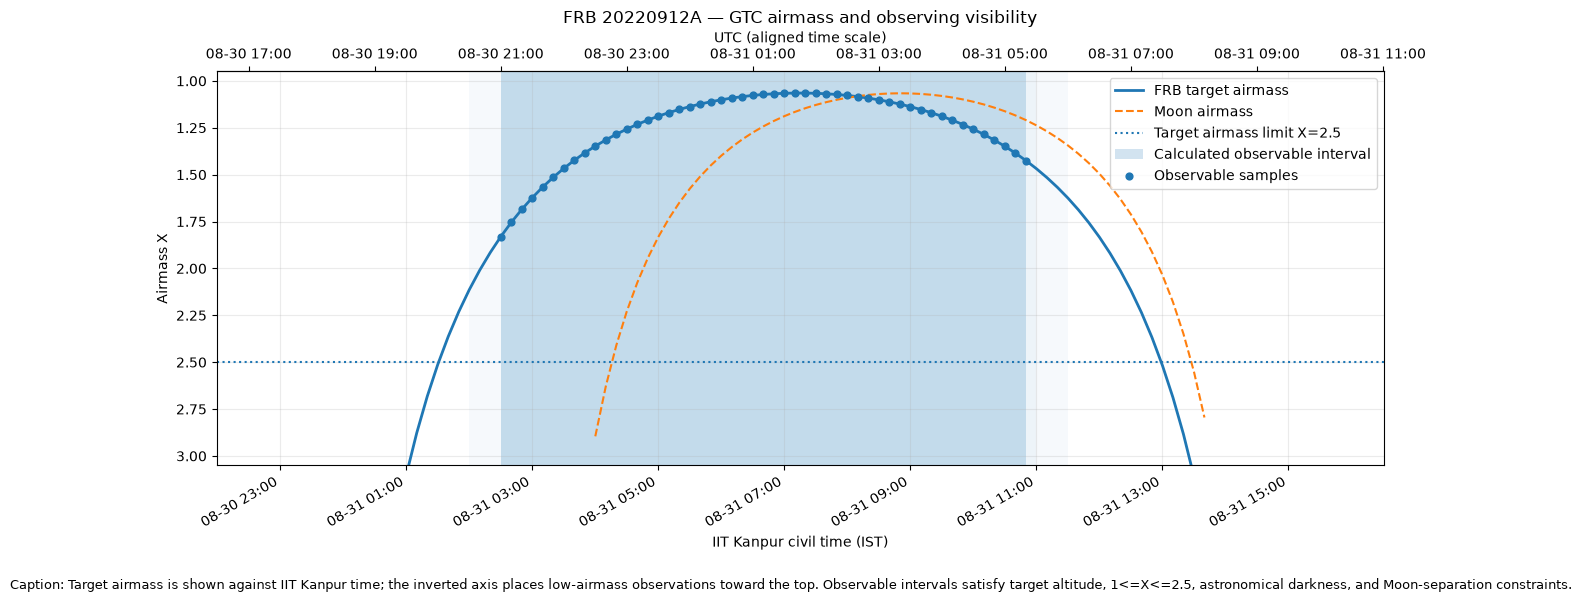


Saved: assignment_outputs\frb_20220912a_gtc_airmass.png


In [23]:
def stitch_windows(times, visibility_state):
    times = Time(times)
    state = np.asarray(visibility_state, dtype=bool)

    if times.ndim != 1 or state.ndim != 1 or len(times) != len(state):
        raise ValueError("times and visibility_state must be equal-length 1D arrays.")

    windows = []
    i = 0

    while i < len(state):
        if not state[i]:
            i += 1
            continue

        start = i
        while i + 1 < len(state) and state[i + 1]:
            i += 1
        end = i

        windows.append((start, end))
        i += 1

    return windows

windows = stitch_windows(times, preferred_visibility)

print("Observable intervals:")
for start_idx, end_idx in windows:
    t_start = times[start_idx]
    t_end = times[end_idx]

    duration = (t_end - t_start).to_value(u.hour)
    best_local = start_idx + int(
        np.nanargmin(target_airmass[start_idx:end_idx + 1])
    )
    midpoint_idx = (start_idx + end_idx) // 2

    print("\nStart UTC:", format_utc(t_start))
    print("End UTC:", format_utc(t_end))
    print("Start IST:", format_iitk(t_start))
    print("End IST:", format_iitk(t_end))
    print("Sample-centre duration:", duration, "hours")
    print("Best target airmass:", target_airmass[best_local])
    print("Midpoint Moon label:", moon_label[midpoint_idx])

# Plot requested in the assignment
fig, ax = plt.subplots(figsize=(13, 6))

iitk_datetimes = times.to_datetime(timezone=IITK_TIMEZONE)
utc_datetimes = times.to_datetime(timezone=timezone.utc)

ax.plot(iitk_datetimes, target_airmass, label="FRB target airmass", linewidth=2)
ax.plot(iitk_datetimes, moon_airmass, "--", label="Moon airmass", linewidth=1.5)

ax.axhline(MAX_AIRMASS, linestyle=":", label="Target airmass limit X=2.5")

# Scheduler-style background bands
night_mask = sun_altitude_deg <= MAX_SUN_ALTITUDE_DEG
twilight_mask = (sun_altitude_deg <= -12) & ~night_mask

# Draw broad bands from the calculated masks
for i in range(len(times) - 1):
    if night_mask[i]:
        ax.axvspan(iitk_datetimes[i], iitk_datetimes[i+1], alpha=0.08)
    elif twilight_mask[i]:
        ax.axvspan(iitk_datetimes[i], iitk_datetimes[i+1], alpha=0.04)

for start_idx, end_idx in windows:
    ax.axvspan(
        iitk_datetimes[start_idx],
        iitk_datetimes[end_idx],
        alpha=0.20,
        label="Calculated observable interval" if start_idx == windows[0][0] else None,
    )

observable_indices = np.where(preferred_visibility)[0]
ax.scatter(
    iitk_datetimes[observable_indices],
    target_airmass[observable_indices],
    marker="o",
    s=24,
    label="Observable samples",
    zorder=5,
)

ax.set_ylim(3.05, 0.95)
ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur civil time (IST)")
ax.set_title("FRB 20220912A — GTC airmass and observing visibility")
ax.grid(alpha=0.25)
ax.legend(loc="best")

# Aligned UTC axis above the main IST axis
secax = ax.secondary_xaxis(
    "top",
    functions=(
        lambda x: x,
        lambda x: x,
    ),
)
secax.set_xlabel("UTC (aligned time scale)")
secax.xaxis.set_major_locator(mdates.HourLocator(interval=2, tz=timezone.utc))
secax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=timezone.utc))

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2, tz=IITK_TIMEZONE))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=IITK_TIMEZONE))
fig.autofmt_xdate()

caption = (
    "Caption: Target airmass is shown against IIT Kanpur time; the inverted axis "
    "places low-airmass observations toward the top. Observable intervals satisfy "
    "target altitude, 1<=X<=2.5, astronomical darkness, and Moon-separation constraints."
)
fig.text(0.5, 0.01, caption, ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0.05, 1, 1))

airmass_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
fig.savefig(airmass_path, dpi=180, bbox_inches="tight")
plt.show()

print("\nSaved:", airmass_path)

Explanation : The calcuated observing intervals show the periods when the FRB satisfies all the required observing conditions at GTC simultaneously . The airmass figure shows how the target and moon airmass changes with time and highlights the intervals during which the FRB is observable. The main limitation of 10 minute grid is the exact start and exact end of an observing interval may occur between two samples, so the reported intervals are approximate.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [24]:
q19_start = Time("2026-09-01T00:00:00", scale="utc")
q19_times = q19_start + np.arange(145) * 10 * u.min

q19_frame = AltAz(
    obstime=q19_times,
    location=gtc_location,
    pressure=0 * u.hPa,
)
q19_altaz = frb_icrs.transform_to(q19_frame)
q19_alt = q19_altaz.alt.to_value(u.deg)
q19_airmass = np.array(q19_altaz.secz, dtype=float)
q19_airmass[
    (q19_alt <= 0)
    | (~np.isfinite(q19_airmass))
    | (q19_airmass < 1)
] = np.nan

q19_sun_alt = get_sun(q19_times).transform_to(q19_frame).alt.to_value(u.deg)

q19_visible = (
    (q19_alt >= 20.0)
    & np.isfinite(q19_airmass)
    & (q19_airmass <= 2.5)
    & (q19_sun_alt <= -18.0)
)

q19_windows = stitch_windows(q19_times, q19_visible)

print(" visibility windows for 2026-09-01:")
for start_idx, end_idx in q19_windows:
    start = q19_times[start_idx]
    end = q19_times[end_idx]
    duration = (end - start).to_value(u.hour)

    print("\nUTC:", format_utc(start), "to", format_utc(end))
    print("IST:", format_iitk(start), "to", format_iitk(end))
    print("Sample-centre duration:", duration, "hours")

if not q19_windows:
    print("No sampled visibility interval was found.")

 visibility windows for 2026-09-01:

UTC: 2026-09-01 00:00:00 UTC to 2026-09-01 05:20:00 UTC
IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Sample-centre duration: 5.333333333333333 hours

UTC: 2026-09-01 21:00:00 UTC to 2026-09-02 00:00:00 UTC
IST: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Sample-centre duration: 3.0 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [27]:
import imageio.v2 as imageio

NSIDE = 16
NPIX = hp.nside2npix(NSIDE)

# HEALPix longitude/latitude for each pixel.
theta, longitude = hp.pix2ang(NSIDE, np.arange(NPIX))
sky_ra_deg = np.rad2deg(longitude)
sky_dec_deg = 90.0 - np.rad2deg(theta)

# Weekly dates from 2026-08-30 through 2027-08-29.
weekly_dates = [
    Time("2026-08-30T00:00:00", scale="utc") + i * 7 * u.day
    for i in range(53)
]

frames_dir = OUTPUT_DIR / "q20_weekly_frames"
frames_dir.mkdir(parents=True, exist_ok=True)
frame_paths = []

# Use 30-minute samples through each UTC date. The map stores hours visible
# during astronomical night with altitude >= 20 deg and X <= 2.5.
minutes_per_sample = 30
sample_offsets = np.arange(0, 24 * 60, minutes_per_sample) * u.min

sky_dec_rad = np.deg2rad(sky_dec_deg)
sin_dec = np.sin(sky_dec_rad)
cos_dec = np.cos(sky_dec_rad)
phi_rad = np.deg2rad(GTC_LATITUDE_DEG)
sin_phi = np.sin(phi_rad)
cos_phi = np.cos(phi_rad)

for frame_number, date0 in enumerate(weekly_dates):
    sample_times = date0 + sample_offsets

    # LST for all times.
    lst = sample_times.sidereal_time("apparent", longitude=gtc_location.lon)
    lst_rad = lst.to_value(u.rad)

    # Target altitude for every HEALPix pixel at every time.
    hour_angle = lst_rad[:, None] - np.deg2rad(sky_ra_deg)[None, :]
    sin_alt = (
        sin_phi * sin_dec[None, :]
        + cos_phi * cos_dec[None, :] * np.cos(hour_angle)
    )
    alt_deg = np.rad2deg(np.arcsin(np.clip(sin_alt, -1, 1)))

    # Geometric airmass approximation X = sec(z) = 1/cos(z) = 1/sin(h).
    # It is used only for h > 0 and then limited to X <= 2.5.
    sin_alt_safe = np.sin(np.deg2rad(alt_deg))
    x = np.full_like(alt_deg, np.nan)
    positive = alt_deg > 0
    x[positive] = 1.0 / sin_alt_safe[positive]

    # Sun altitude for the same sample times.
    sun_alt = get_sun(sample_times).transform_to(
        AltAz(obstime=sample_times, location=gtc_location, pressure=0 * u.hPa)
    ).alt.to_value(u.deg)

    visible = (
        (alt_deg >= MIN_TARGET_ALTITUDE_DEG)
        & np.isfinite(x)
        & (x >= 1)
        & (x <= MAX_AIRMASS)
        & (sun_alt[:, None] <= MAX_SUN_ALTITUDE_DEG)
    )

    visibility_hours = visible.sum(axis=0) * (minutes_per_sample / 60.0)

    fig = plt.figure(figsize=(10, 5.8))
    hp.mollview(
        visibility_hours,
        fig=fig.number,
        title=f"GTC all-sky visibility — {date0.utc.datetime:%Y-%m-%d}",
        unit="hours visible",
        min=0,
        max=12,
        xsize=900,
        cbar=True,
    )


    hp.graticule()
    fig = plt.gcf()
    fig.text(
        0.5,
        0.015,
        "Weekly all-sky map: astronomical night + altitude >= 20° + GTC airmass <= 2.5",
        ha="center",
        fontsize=9,
    )
    frame_path = frames_dir / f"gtc_visibility_{frame_number:03d}_{date0.utc.datetime:%Y%m%d}.png"
    fig.savefig(frame_path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    frame_paths.append(str(frame_path))

# Combine PNG frames into GIF.
gif_path = OUTPUT_DIR / "gtc_all_sky_visibility_one_year.gif"
images = [imageio.imread(path) for path in frame_paths]
imageio.mimsave(gif_path, images, duration=0.5, loop=0)

print("Number of weekly frames:", len(frame_paths))
print("First frame:", frame_paths[0])
print("Last frame:", frame_paths[-1])
print("GIF:", gif_path)



# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Number of weekly frames: 53
First frame: assignment_outputs\q20_weekly_frames\gtc_visibility_000_20260830.png
Last frame: assignment_outputs\q20_weekly_frames\gtc_visibility_052_20270829.png
GIF: assignment_outputs\gtc_all_sky_visibility_one_year.gif


Explanation : The animation shows the change in the sky observable from the GTC over one year. The observable region changes with date because the earth moves around the sun , causing different parts of the sky to be visible during night at different times of the year. Therefore, some regions that are visible in one month are not visible in another month , while other new regions become visible.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
